# Exercise - Stripping Caps


#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$


# 1. Pricing Floors


### Data

The file `data/cap_curves_2025-06-30.xlsx` has market data on the following curves:
* swap rates (SOFR)
* discount factors
* forward rates 
* flat volatilites

A few details
* the swap and forward rates are quarterly compounded.
* the flat volatilites are (Black) quotes on caps containing caplets ranging from expiration of $\tau=.5$ to $\tau=T$.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
CAP_FILE_PATH = '../data/cap_curves_2025-06-30.xlsx'
SHEET_NAME = 'rate curves 2025-06-30'
cap_data = pd.read_excel(CAP_FILE_PATH, sheet_name=SHEET_NAME)
display(cap_data.head())

,tenor,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
0,0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
1,0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
2,0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
3,1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
4,1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341


### 1.1.

Recall that a floor is a portfolio of floorlets which
* depend on the realized interest rate one quarter before the expiration.
* each have the same strike interest rate.

Use Black's formula to price **just one floorlet**
* expiring at `T=3`
* struck at the `T=3` swap rate
* notional of `100`
* quarterly frequency


In [42]:
# pricing a floorlet
from scipy.stats import norm
def calc_caplet_floorlet_price(vol, strike, fwd_rate, discount_factor, expiry, freq = 4, type = 'caplet'):
    effective_expiry = expiry - 1/freq # assuming the expiry is present in years
    d1 = (np.log(fwd_rate/strike) + vol**2 / 2 * effective_expiry) / (vol * np.sqrt(effective_expiry))
    d2 = d1 - (vol * np.sqrt(effective_expiry))
    
    price = None
    if type == 'caplet':
        price = discount_factor * (fwd_rate * norm.cdf(d1) - strike * norm.cdf(d2))
    else:
        price = discount_factor * (strike * norm.cdf(-d2) - fwd_rate * norm.cdf(-d1))
    print(f'price of {type} at expiry: {expiry} with vol: {vol:.2f}, strike: {strike:.2f}, fwd rate: {fwd_rate:.2f} = {price}')
    return price


In [43]:
expiry = 3
strike = cap_data.loc[cap_data['tenor'] == expiry, 'swap rates'].values[0]
discount_factor = cap_data.loc[cap_data['tenor'] == expiry, 'discounts'].values[0]
fwd_rate = cap_data.loc[cap_data['tenor'] == expiry, 'forwards'].values[0]
vol = cap_data.loc[cap_data['tenor'] == expiry, 'fwd vols'].values[0]
freq = 4
notional = 100

floorlet_price = notional/freq * calc_caplet_floorlet_price(vol, strike, fwd_rate, discount_factor, expiry, type = 'floorlet')

print(f'price of the floorlet at T=3 struck at T=3 swap rate: {floorlet_price:.2f}')

price of floorlet at expiry: 3 with vol: 0.28, strike: 0.03, fwd rate: 0.03 = 0.005717921859834761
price of the floorlet at T=3 struck at T=3 swap rate: 0.14


### 1.2.

Use Black's formula to price the entire floor with expiration of `T=3`.

The floor has floorlets at `quarterly` frequency, except the first quarter.


In [44]:
def calc_cap_floor_price(flat_vol, strike, rates_df, overall_expiry, freq=4, type='cap', verbose=True):
    start = 2 / freq
    end = overall_expiry
    price = 0
    while round(start, 10) <= round(end, 10):   # FIX: was `end - start > 0.1`, which always skipped the last caplet
        cur_price = 0
        expiry = round(start, 4)                 # FIX: round to avoid float accumulation in DataFrame lookup
        effective_expiry = expiry - 1 / freq
        discount_factor = rates_df.loc[rates_df['tenor'] == expiry, 'discounts'].values[0]
        fwd_rate = rates_df.loc[rates_df['tenor'] == expiry, 'forwards'].values[0]
        d1 = (np.log(fwd_rate / strike) + flat_vol**2 / 2 * effective_expiry) / (flat_vol * np.sqrt(effective_expiry))
        d2 = d1 - (flat_vol * np.sqrt(effective_expiry))
        if type == 'cap':
            cur_price = discount_factor * (fwd_rate * norm.cdf(d1) - strike * norm.cdf(d2))
        else:
            cur_price = discount_factor * (strike * norm.cdf(-d2) - fwd_rate * norm.cdf(-d1))

        if verbose:
            print(f'price of {type} at expiry: {expiry} with flat vol: {flat_vol:.2f}, strike: {strike:.2f}, fwd rate: {fwd_rate:.2f} = {cur_price}')
        price += cur_price if cur_price > 0 else 0
        if cur_price < 0 and verbose:
            print(f'negative price at expiry: {expiry} with flat vol: {flat_vol:.2f}, strike: {strike:.2f}, fwd rate: {fwd_rate:.2f} = {cur_price}')

        start += 1 / freq

    if verbose:
        print(f'price of {type} with flat vol: {flat_vol:.2f}, strike: {strike:.2f} = {price}')
    return price

In [45]:
expiry = 3
notional = 100
freq = 4
strike = cap_data.loc[cap_data['tenor'] == expiry, 'swap rates'].values[0]
flat_vol = cap_data.loc[cap_data['tenor'] == expiry, 'flat vols'].values[0]

floor_price = notional /freq * calc_cap_floor_price(flat_vol, strike, cap_data, expiry, type = 'floor')
print('=='*50)
print(f'price of the floor with flat vol at T=3 struck at T=3 swap rate: {floor_price:.2f}')
print('=='*50)

price of floor at expiry: 0.5 with flat vol: 0.29, strike: 0.03, fwd rate: 0.04 = 0.0003747301198969583
price of floor at expiry: 0.75 with flat vol: 0.29, strike: 0.03, fwd rate: 0.04 = 0.0016488485824339017
price of floor at expiry: 1.0 with flat vol: 0.29, strike: 0.03, fwd rate: 0.03 = 0.003009923549312639
price of floor at expiry: 1.25 with flat vol: 0.29, strike: 0.03, fwd rate: 0.03 = 0.0050024456647815106
price of floor at expiry: 1.5 with flat vol: 0.29, strike: 0.03, fwd rate: 0.03 = 0.005710088799964105
price of floor at expiry: 1.75 with flat vol: 0.29, strike: 0.03, fwd rate: 0.03 = 0.005888649560600601
price of floor at expiry: 2.0 with flat vol: 0.29, strike: 0.03, fwd rate: 0.03 = 0.005991729508660859
price of floor at expiry: 2.25 with flat vol: 0.29, strike: 0.03, fwd rate: 0.03 = 0.006568936171463241
price of floor at expiry: 2.5 with flat vol: 0.29, strike: 0.03, fwd rate: 0.03 = 0.006274284654718849
price of floor at expiry: 2.75 with flat vol: 0.29, strike: 0.03, 

# 2. Stripping Caps


### Data

Continue with the file `data/cap_curves_2025-06-30.xlsx`.


### 2.1 Cap Prices

For each cap maturity, $.5\le T \le 10$, use the flat volatility to get the price of the cap.

Report the cap prices across expirations, $.5\le T \le 10$.

Plot the cap prices across expirations.


price of cap at expiry: 0.5 with flat vol: 0.16, strike: 0.04, fwd rate: 0.04 = 0.0006287422788836823
price of cap with flat vol: 0.16, strike: 0.04 = 0.0006287422788836823
cap price at expiry 0.5: 0.02
price of cap at expiry: 0.5 with flat vol: 0.20, strike: 0.04, fwd rate: 0.04 = 0.002228203940701326
price of cap at expiry: 0.75 with flat vol: 0.20, strike: 0.04, fwd rate: 0.04 = 0.0013634648958667519
price of cap at expiry: 1.0 with flat vol: 0.20, strike: 0.04, fwd rate: 0.03 = 0.001021873285421399
price of cap with flat vol: 0.20, strike: 0.04 = 0.004613542121989477
cap price at expiry 1.0: 0.12
price of cap at expiry: 0.5 with flat vol: 0.27, strike: 0.04, fwd rate: 0.04 = 0.00428528952579828
price of cap at expiry: 0.75 with flat vol: 0.27, strike: 0.04, fwd rate: 0.04 = 0.0030327082224746353
price of cap at expiry: 1.0 with flat vol: 0.27, strike: 0.04, fwd rate: 0.03 = 0.002471256569730917
price of cap at expiry: 1.25 with flat vol: 0.27, strike: 0.04, fwd rate: 0.03 = 0.00160

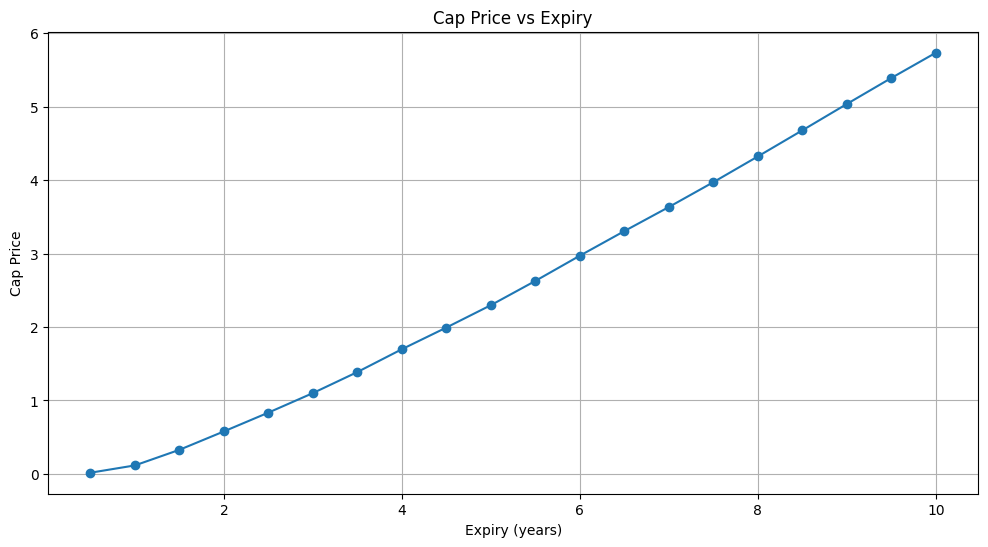

In [46]:
start = 0.5; end = 10
expiries = []
prices = []
while start <= end:
    expiry = start
    strike = cap_data.loc[cap_data['tenor'] == expiry, 'swap rates'].values[0]
    flat_vol = cap_data.loc[cap_data['tenor'] == expiry, 'flat vols'].values[0]
    cap_price = notional /freq * calc_cap_floor_price(flat_vol, strike, cap_data, expiry, type = 'cap')
    print(f'cap price at expiry {expiry}: {cap_price:.2f}')
    expiries.append(expiry)
    prices.append(cap_price)
    start += 0.5
plt.figure(figsize=(12, 6))
plt.plot(expiries, prices, marker='o')
plt.title('Cap Price vs Expiry')
plt.xlabel('Expiry (years)')
plt.ylabel('Cap Price')
plt.grid()
plt.show()


### 2.2 Caplet Prices and Forward Volatilities

Using the cap prices, strip out the
* caplet prices
* forward volatility at $\tau$ which properly prices caplet $\tau$ using Black's formula.

List and plot the forward volatility versus the flat volatiltiy.


In [47]:
def calc_fwd_vol(strike, expiry, discount_factor, fwd_rate, price, notional=100, freq=4, type='caplet'):
    effective_expiry = expiry - 1 / freq

    def objective_function(vol):
        d1 = (np.log(fwd_rate / strike) + vol**2 / 2 * effective_expiry) / (vol * np.sqrt(effective_expiry))
        d2 = d1 - (vol * np.sqrt(effective_expiry))
        if type == 'caplet':
            theoretical_price = discount_factor * (fwd_rate * norm.cdf(d1) - strike * norm.cdf(d2)) * notional / freq
        else:
            theoretical_price = discount_factor * (strike * norm.cdf(-d2) - fwd_rate * norm.cdf(-d1)) * notional / freq
        return theoretical_price - price

    from scipy.optimize import root_scalar
    result = root_scalar(objective_function, bracket=[1e-6, 5], method='bisect')  # FIX: bracket must be strictly positive
    if result.converged:
        print(f'calibrated forward vol for {type} at expiry: {expiry:.2f} | strike: {strike:.4f}, fwd rate: {fwd_rate:.4f}, price: {price:.4f} => vol: {result.root:.4f}')
        return result.root

Cap prices at quarterly tenors:
  T=0.50: 0.0157
  T=0.75: 0.0536
  T=1.00: 0.1153
  T=1.25: 0.2144
  T=1.50: 0.3278
  T=1.75: 0.4504
  T=2.00: 0.5784
  T=2.25: 0.7057
  T=2.50: 0.8345
  T=2.75: 0.9650
  T=3.00: 1.1002
  T=3.25: 1.2410
  T=3.50: 1.3871
  T=3.75: 1.5428
  T=4.00: 1.6979
  T=4.25: 1.8478
  T=4.50: 1.9931
  T=4.75: 2.1439
  T=5.00: 2.2977
  T=5.25: 2.4596
  T=5.50: 2.6280
  T=5.75: 2.8000
  T=6.00: 2.9716
  T=6.25: 3.1409
  T=6.50: 3.3065
  T=6.75: 3.4701
  T=7.00: 3.6342
  T=7.25: 3.8018
  T=7.50: 3.9727
  T=7.75: 4.1467
  T=8.00: 4.3232
  T=8.25: 4.5004
  T=8.50: 4.6789
  T=8.75: 4.8582
  T=9.00: 5.0377
  T=9.25: 5.2154
  T=9.50: 5.3916
  T=9.75: 5.5653
  T=10.00: 5.7354

caplet price at expiry 0.75: 0.037856
calibrated forward vol for caplet at expiry: 0.75 | strike: 0.0394, fwd rate: 0.0364, price: 0.0379 => vol: 0.2624

caplet price at expiry 1.00: 0.061764
calibrated forward vol for caplet at expiry: 1.00 | strike: 0.0381, fwd rate: 0.0342, price: 0.0618 => vol: 0.3

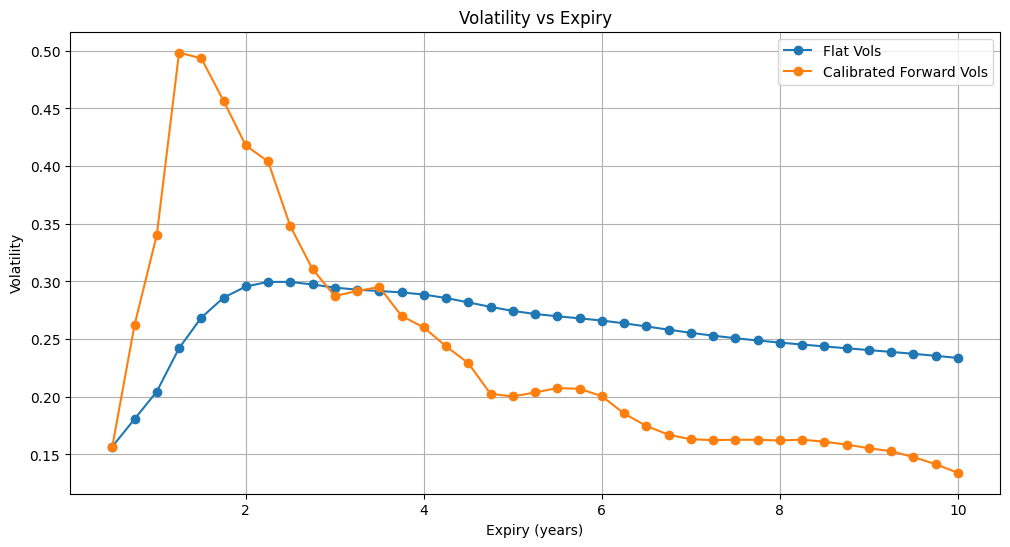

In [48]:
notional = 100
freq = 4

# ── Step 1: recompute cap prices at QUARTERLY (0.25-year) intervals ──────────
# We need one cap price per caplet tenor so that each consecutive difference
# isolates exactly one caplet.  Section 2.1 used 0.5-year steps, which means
# each difference spans two caplets and you can't back out a single vol from it.
quarterly_expiries = []
quarterly_prices   = []

t = 0.5
while t <= 10.0 + 1e-9:
    expiry   = round(t, 4)
    strike   = cap_data.loc[cap_data['tenor'] == expiry, 'swap rates'].values[0]
    flat_vol = cap_data.loc[cap_data['tenor'] == expiry, 'flat vols'].values[0]
    cap_price = notional / freq * calc_cap_floor_price(
        flat_vol, strike, cap_data, expiry, type='cap', verbose=False   # suppress per-caplet noise
    )
    quarterly_expiries.append(expiry)
    quarterly_prices.append(cap_price)
    t += 0.25

print("Cap prices at quarterly tenors:")
for e, p in zip(quarterly_expiries, quarterly_prices):
    print(f"  T={e:.2f}: {p:.4f}")

# ── Step 2: strip caplets and calibrate forward vols ─────────────────────────
# caplet(T_i) = Cap(T_i) - Cap(T_{i-1})
# We keep `quarterly_prices` unmodified throughout the loop (no shallow-copy bug).
flat_vols_data = cap_data.loc[
    (cap_data['tenor'] >= 0.5) & (cap_data['tenor'] <= 10.0), 'flat vols'
].values                                     # 38 values, one per quarterly tenor

fwd_vols = []

# T=0.5 cap is a single caplet → forward vol equals the flat vol directly
fwd_vols.append(cap_data.loc[cap_data['tenor'] == quarterly_expiries[0], 'flat vols'].values[0])

for i in range(1, len(quarterly_expiries)):
    caplet_price = quarterly_prices[i] - quarterly_prices[i - 1]   # FIX: uses original list each time
    print(f'\ncaplet price at expiry {quarterly_expiries[i]:.2f}: {caplet_price:.6f}')

    if caplet_price <= 0:
        print(f'  Warning: non-positive caplet price — skipping vol calibration')
        fwd_vols.append(np.nan)
        continue

    strike          = cap_data.loc[cap_data['tenor'] == quarterly_expiries[i], 'swap rates'].values[0]
    discount_factor = cap_data.loc[cap_data['tenor'] == quarterly_expiries[i], 'discounts'].values[0]
    fwd_rate        = cap_data.loc[cap_data['tenor'] == quarterly_expiries[i], 'forwards'].values[0]

    fwd_vol = calc_fwd_vol(
        strike, quarterly_expiries[i], discount_factor, fwd_rate, caplet_price,
        notional=notional, freq=freq, type='caplet'
    )
    fwd_vols.append(fwd_vol)

# ── Step 3: plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
plt.plot(quarterly_expiries, flat_vols_data, marker='o', label='Flat Vols')
plt.plot(quarterly_expiries, fwd_vols,       marker='o', label='Calibrated Forward Vols')
plt.title('Volatility vs Expiry')
plt.xlabel('Expiry (years)')
plt.ylabel('Volatility')
plt.grid()
plt.legend()
plt.show()